# [Lab 5-1] Autoencoder 종합 실습
### (기초 잠재공간 시각화, Denoising Autoencoder, Anomaly Detection)

본 실습에서는 비지도 학습(Unsupervised Learning)의 대표적인 신경망인 **Autoencoder(오토인코더)**의 기본 구조와 동작 원리를 배우고, 실제 산업/제조 및 컴퓨터 비전에서 가장 널리 활용되는 **3대 응용 분야**를 단계별로 실습합니다.

---

### 📚 Autoencoder의 핵심 구조와 원리
- **인코더(Encoder)**: 고차원의 입력 데이터 $x$를 핵심적인 정보만 압축된 저차원의 **잠재 공간 벡터(Latent Vector) $z$**로 변환합니다. ($z = f(x)$)
- **병목 구간(Bottleneck)**: 정보의 병목을 두어 불필요한 노이즈를 버리고 데이터의 본질적인 특징(Manifold)만 추출하도록 강제합니다.
- **디코더(Decoder)**: 잠재 벡터 $z$를 다시 원래 차원의 데이터 $\hat{x}$로 복원(Reconstruction)합니다. ($\hat{x} = g(z)$)
- **손실 함수(Reconstruction Loss)**: 입력 $x$와 복원된 $\hat{x}$ 사이의 차이를 최소화합니다. ($L(x, \hat{x}) = \|x - \hat{x}\|^2$)

---

### 🛠️ 실습 구성
1. **Part 1: 기본 Autoencoder와 잠재 공간(Latent Space) 시각화**
   - 차원 축소 및 압축, 잠재 공간 벡터 추출 및 t-SNE 2D 매핑
2. **Part 2: Denoising Autoencoder (DAE, 노이즈 제거 오토인코더)**
   - 센서/환경 노이즈 주입 후 합성곱(CNN) 기반 DAE로 깨끗한 원본 이미지 복원
3. **Part 3: Autoencoder 기반 비지도 이상치 탐지 (Anomaly Detection)**
   - 정상 데이터만 학습시킨 후, 비정상 데이터 입력 시 재구성 오차(Reconstruction Error) 급증 원리를 이용한 결함 판정

In [1]:
# 필수 라이브러리 임포트 및 시각화 설정
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 한글 폰트 및 마이너스 부호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"TensorFlow 버전: {tf.__version__}")
print(f"NumPy 버전: {np.__version__}")

TensorFlow 버전: 2.21.0
NumPy 버전: 2.4.6


---
# Part 1. 기본 Autoencoder와 잠재 공간(Latent Space) 시각화

첫 번째 실습에서는 완전 연결 계층(Dense Layer) 기반의 기본 오토인코더를 구축하여 784차원($28 \times 28$)의 MNIST 손글씨 이미지를 64차원의 잠재 공간으로 압축한 뒤 복원해봅니다.
압축된 잠재 벡터를 추출하여 t-SNE로 2차원 투영 시각화를 수행합니다.

### 1.1 데이터 준비 (MNIST)

In [2]:
# MNIST 데이터셋 로드
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 0 ~ 1 사이로 정규화
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 4차원 텐서 형태로 reshape (샘플 수, 28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"훈련 데이터 형태: {x_train.shape}")
print(f"테스트 데이터 형태: {x_test.shape}")

훈련 데이터 형태: (60000, 28, 28, 1)
테스트 데이터 형태: (10000, 28, 28, 1)


### 1.2 Autoencoder 모델 정의
- **인코더**: $28 \times 28 \times 1 \to 784 \to \text{Dense}(128) \to \text{Dense}(64, \text{Latent})$
- **디코더**: $64 \to \text{Dense}(128) \to \text{Dense}(784, \text{Sigmoid}) \to 28 \times 28 \times 1$

In [3]:
latent_dim = 64

# [Encoder 정의]
input_img = layers.Input(shape=(28, 28, 1), name="Input_Image")
x = layers.Flatten(name="Flatten")(input_img)
x = layers.Dense(128, activation="relu", name="Encoder_Dense_1")(x)
latent = layers.Dense(latent_dim, activation="relu", name="Latent_Space")(x)

encoder = models.Model(input_img, latent, name="Encoder")
encoder.summary()

# [Decoder 정의]
latent_input = layers.Input(shape=(latent_dim,), name="Latent_Input")
x = layers.Dense(128, activation="relu", name="Decoder_Dense_1")(latent_input)
x = layers.Dense(28 * 28, activation="sigmoid", name="Decoder_Output")(x)
decoded = layers.Reshape((28, 28, 1), name="Reshape_Image")(x)

decoder = models.Model(latent_input, decoded, name="Decoder")
decoder.summary()

# [Autoencoder 결합]
autoencoder_input = layers.Input(shape=(28, 28, 1), name="AE_Input")
encoded_img = encoder(autoencoder_input)
reconstructed_img = decoder(encoded_img)

autoencoder = models.Model(autoencoder_input, reconstructed_img, name="Autoencoder")
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Dense_1 (Dense)         │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,736 (424.75 KB)

 Trainable params: 108,736 (424.75 KB)

 Non-trainable params: 0 (0.00 B)

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Latent_Input (InputLayer)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Dense_1 (Dense)         │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Output (Dense)          │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape_Image (Reshape)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,456 (427.56 KB)

 Trainable params: 109,456 (427.56 KB)

 Non-trainable params: 0 (0.00 B)

### 1.3 모델 학습 및 재구성 확인

In [4]:
# Autoencoder 학습: 입력과 타겟이 모두 x_train
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/10


  1/235 ━━━━━━━━━━━━━━━━━━━━ 3:42 950ms/step - loss: 0.6953

  8/235 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6812    

 14/235 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6539

 20/235 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6189

...

213/235 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0847

220/235 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0847

226/235 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0847

232/235 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0847

235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0844 - val_loss: 0.0828


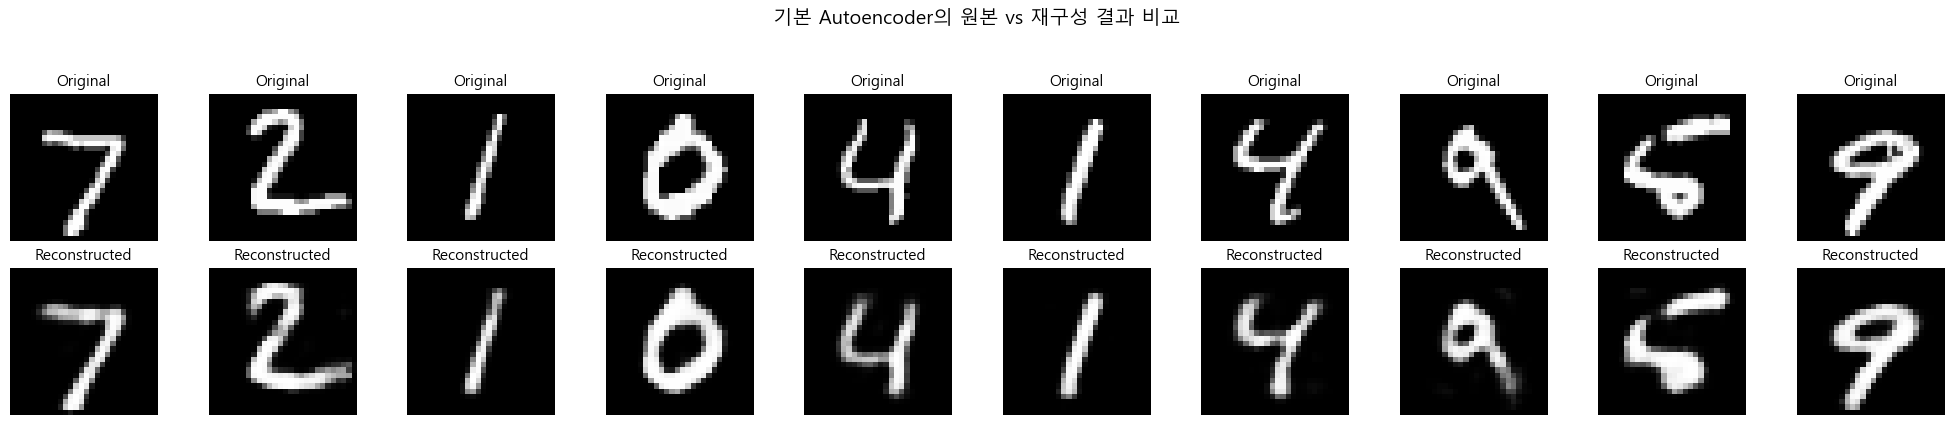

In [5]:
# 원본 이미지와 재구성(Reconstruction) 이미지 비교 시각화
decoded_imgs = autoencoder.predict(x_test, verbose=0)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # 원본 이미지
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original", fontsize=11)
    plt.axis("off")

    # 재구성 이미지
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed", fontsize=11)
    plt.axis("off")

plt.suptitle("기본 Autoencoder의 원본 vs 재구성 결과 비교", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### 1.4 잠재 공간(Latent Space) 추출 및 t-SNE 2D 시각화
64차원의 잠재 공간에 압축된 벡터를 t-SNE(t-Distributed Stochastic Neighbor Embedding)를 이용하여 2차원으로 축소하고, 동일한 숫자 클래스끼리 가깝게 군집을 이루고 있는지 확인합니다.

추출된 잠재 벡터 크기: (10000, 64)


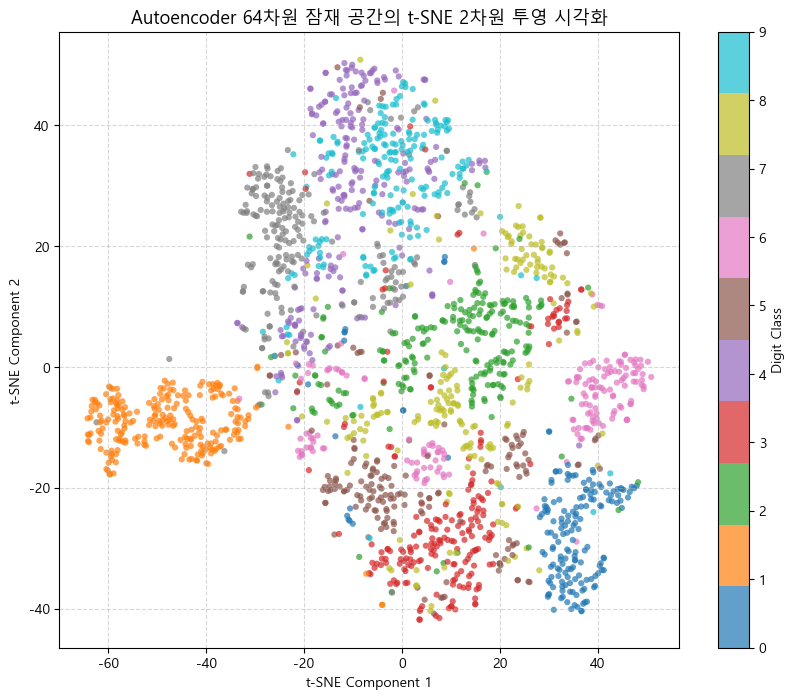

In [6]:
# 테스트 데이터에 대한 잠재 벡터 추출
latent_vectors = encoder.predict(x_test, verbose=0)
print(f"추출된 잠재 벡터 크기: {latent_vectors.shape}")

# t-SNE를 이용해 2차원으로 축소 (계산 속도를 위해 2,000개 샘플 사용)
tsne = TSNE(n_components=2, random_state=42)
latent_tsne = tsne.fit_transform(latent_vectors[:2000])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=y_test[:2000], cmap="tab10", alpha=0.7, edgecolors='none', s=20)
plt.colorbar(scatter, ticks=range(10), label="Digit Class")
plt.title("Autoencoder 64차원 잠재 공간의 t-SNE 2차원 투영 시각화", fontsize=13)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

---
# Part 2. Denoising Autoencoder (DAE, 노이즈 제거 오토인코더)

실제 산업 현장(비전 센서, X-ray 검사기 등)에서 수집되는 영상 데이터는 조명 변화나 센서 잡음(Noise)을 포함하는 경우가 많습니다.
**Denoising Autoencoder(DAE)**는 손상된 입력($x_{noisy}$)으로부터 깨끗한 원본($x_{clean}$)을 복원하도록 학습하여, **노이즈 필터링 및 강건한 특징 추출(Robust Feature Extraction)**을 수행합니다.

### 2.1 가우시안 노이즈 주입

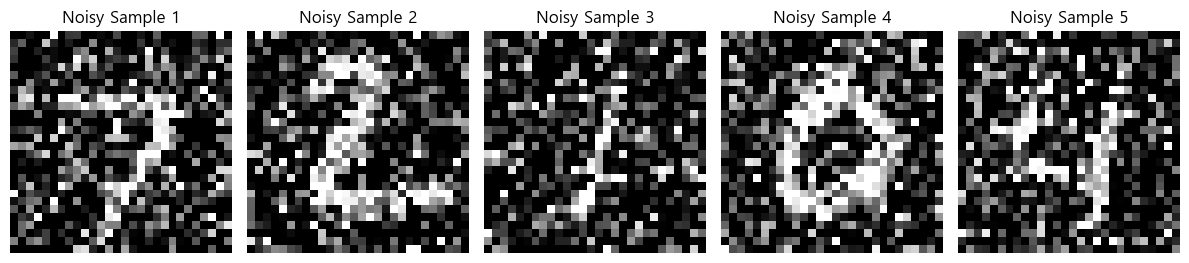

In [7]:
# 가우시안 노이즈 추가
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# 픽셀값을 [0, 1] 범위로 클리핑
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

# 노이즈 주입된 샘플 시각화
plt.figure(figsize=(12, 3))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title(f"Noisy Sample {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### 2.2 Convolutional Denoising Autoencoder 모델 정의
이미지의 공간적 특징(Spatial Feature)을 효과적으로 복원하기 위해 **합성곱(Conv2D) 및 업샘플링(UpSampling2D)** 계층으로 모델을 구성합니다.

In [8]:
# Conv2D 기반 Denoising Autoencoder 구조
input_noisy = layers.Input(shape=(28, 28, 1))

# [Encoder]
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_noisy)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded_dae = layers.MaxPooling2D((2, 2), padding='same')(x)

# [Decoder]
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded_dae)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded_dae = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

dae_model = models.Model(input_noisy, decoded_dae, name="Denoising_Autoencoder")
dae_model.compile(optimizer='adam', loss='binary_crossentropy')
dae_model.summary()

Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 노이즈 제거 모델 학습 ($x_{noisy} \to x_{clean}$)

In [9]:
# DAE 학습: 입력은 x_train_noisy, 타겟은 깨끗한 x_train
history_dae = dae_model.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

Epoch 1/10


  1/469 ━━━━━━━━━━━━━━━━━━━━ 6:29 833ms/step - loss: 0.6835

  5/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.6467   

  9/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.6174

 13/469 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.5995

...

454/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0987

458/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0987

462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0987

466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0987

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0985 - val_loss: 0.0978


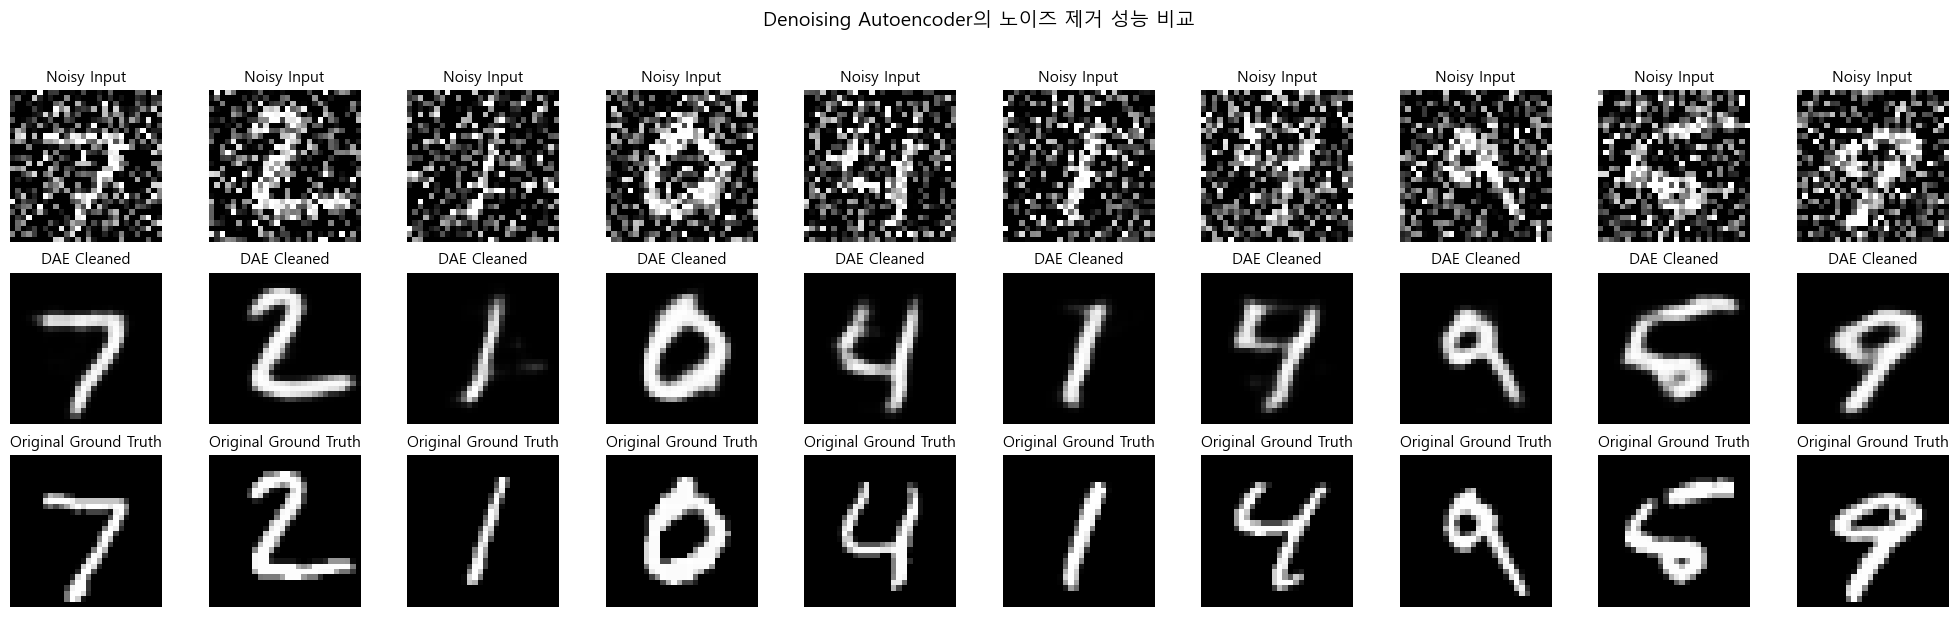

In [10]:
# 노이즈 제거 복원 결과 시각화
decoded_clean = dae_model.predict(x_test_noisy, verbose=0)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # 1. 노이즈 주입된 이미지
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Input", fontsize=11)
    plt.axis("off")

    # 2. DAE가 복원한 깨끗한 이미지
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_clean[i].reshape(28, 28), cmap='gray')
    plt.title("DAE Cleaned", fontsize=11)
    plt.axis("off")

    # 3. 실제 원본 깨끗한 이미지
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original Ground Truth", fontsize=11)
    plt.axis("off")

plt.suptitle("Denoising Autoencoder의 노이즈 제거 성능 비교", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Part 3. Autoencoder 기반 비지도 이상치 탐지 (Anomaly Detection)

제조 공정에서는 불량품(Anomaly) 데이터가 정상품(Normal)에 비해 매우 희소하여 지도 학습 분류기 학습이 어렵습니다.
**Autoencoder 기반 이상치 탐지**는 **정상 데이터만으로 Autoencoder를 학습**시킵니다.
- **정상 데이터 입력 시**: 모델이 학습한 패턴이므로 **재구성 오차(Reconstruction Error)가 매우 낮음**
- **비정상 데이터 입력 시**: 모델이 학습한 적 없는 패턴이므로 **재구성 오차가 급증함!**
- 오차가 사전에 설정한 **임계값(Threshold)**보다 크면 이상치(불량품)로 판정합니다.

### 3.1 정상 데이터(숫자 '0')와 비정상 데이터(숫자 1~9) 분리

In [11]:
# 정상 클래스: 숫자 '0', 이상 클래스: 숫자 '1' ~ '9'
normal_class = 0

# 훈련셋: 정상 데이터만 사용
x_train_normal = x_train[y_train == normal_class]

# 테스트셋: 정상과 비정상 분리
x_test_normal = x_test[y_test == normal_class]
x_test_anomaly = x_test[y_test != normal_class]

print(f"정상 훈련 데이터 개수 ('0'): {len(x_train_normal):,}개")
print(f"정상 테스트 데이터 개수 ('0'): {len(x_test_normal):,}개")
print(f"비정상 테스트 데이터 개수 ('1~9'): {len(x_test_anomaly):,}개")

정상 훈련 데이터 개수 ('0'): 5,923개
정상 테스트 데이터 개수 ('0'): 980개
비정상 테스트 데이터 개수 ('1~9'): 9,020개


### 3.2 정상 데이터 전용 Autoencoder 모델 정의 및 학습

In [12]:
# 이상 탐지용 소형 Autoencoder
ad_input = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Flatten()(ad_input)
x = layers.Dense(64, activation="relu")(x)
ad_latent = layers.Dense(16, activation="relu")(x)  # 강력한 병목(16차원)

# Decoder
x = layers.Dense(64, activation="relu")(ad_latent)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
ad_decoded = layers.Reshape((28, 28, 1))(x)

ad_autoencoder = models.Model(ad_input, ad_decoded, name="Anomaly_Detector_AE")
ad_autoencoder.compile(optimizer="adam", loss="mse")

# 정상 데이터('0')만으로 20 에포크 학습
history_ad = ad_autoencoder.fit(
    x_train_normal, x_train_normal,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_normal, x_test_normal),
    verbose=1
)

Epoch 1/20


 1/24 ━━━━━━━━━━━━━━━━━━━━ 12s 548ms/step - loss: 0.2276

14/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2174   

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1622 - val_loss: 0.0739


Epoch 2/20


...

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0237 - val_loss: 0.0230


Epoch 20/20


 1/24 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0228

16/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0228 

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0226 - val_loss: 0.0219


### 3.3 Reconstruction Error(MSE) 계산 및 분포 비교

정상 데이터 평균 재구성 오차: 0.02193
이상 데이터 평균 재구성 오차: 0.07210


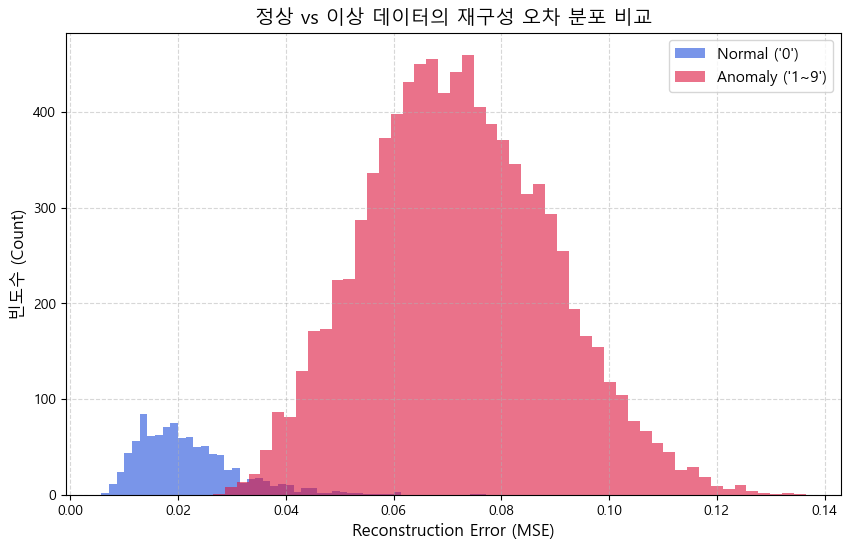

In [13]:
# 정상 및 이상 테스트셋 복원 수행
recon_normal = ad_autoencoder.predict(x_test_normal, verbose=0)
recon_anomaly = ad_autoencoder.predict(x_test_anomaly, verbose=0)

# 샘플별 픽셀 MSE(Reconstruction Error) 계산
mse_normal = np.mean(np.square(x_test_normal - recon_normal), axis=(1, 2, 3))
mse_anomaly = np.mean(np.square(x_test_anomaly - recon_anomaly), axis=(1, 2, 3))

print(f"정상 데이터 평균 재구성 오차: {np.mean(mse_normal):.5f}")
print(f"이상 데이터 평균 재구성 오차: {np.mean(mse_anomaly):.5f}")

# 재구성 오차 분포 히스토그램 시각화
plt.figure(figsize=(10, 6))
plt.hist(mse_normal, bins=50, alpha=0.7, color='royalblue', label="Normal ('0')")
plt.hist(mse_anomaly, bins=50, alpha=0.6, color='crimson', label="Anomaly ('1~9')")
plt.xlabel("Reconstruction Error (MSE)", fontsize=12)
plt.ylabel("빈도수 (Count)", fontsize=12)
plt.title("정상 vs 이상 데이터의 재구성 오차 분포 비교", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 3.4 이상 판정 임계값(Threshold) 설정 및 성능 평가
정상 데이터의 재구성 오차 중 상위 95% 분위수를 이상치 판정 임계값으로 설정합니다.

In [14]:
# 임계값 설정 (정상 데이터의 95 백분위수)
threshold = np.percentile(mse_normal, 95)
print(f"이상 탐지 판정 임계값 (Threshold): {threshold:.5f}\n")

# 실제 레이블: 정상(0), 이상(1)
y_true = np.concatenate([np.zeros(len(mse_normal)), np.ones(len(mse_anomaly))])
y_scores = np.concatenate([mse_normal, mse_anomaly])
y_pred = (y_scores > threshold).astype(int)

# 혼동 행렬 및 분류 지표
cm = confusion_matrix(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_scores)

print("=== Confusion Matrix ===")
print(cm)
print(f"\nROC-AUC Score: {roc_auc:.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=["Normal (0)", "Anomaly (1)"]))

이상 탐지 판정 임계값 (Threshold): 0.04030

=== Confusion Matrix ===
[[ 931   49]
 [ 202 8818]]

ROC-AUC Score: 0.9940

=== Classification Report ===
              precision    recall  f1-score   support

  Normal (0)       0.82      0.95      0.88       980
 Anomaly (1)       0.99      0.98      0.99      9020

    accuracy                           0.97     10000
   macro avg       0.91      0.96      0.93     10000
weighted avg       0.98      0.97      0.98     10000



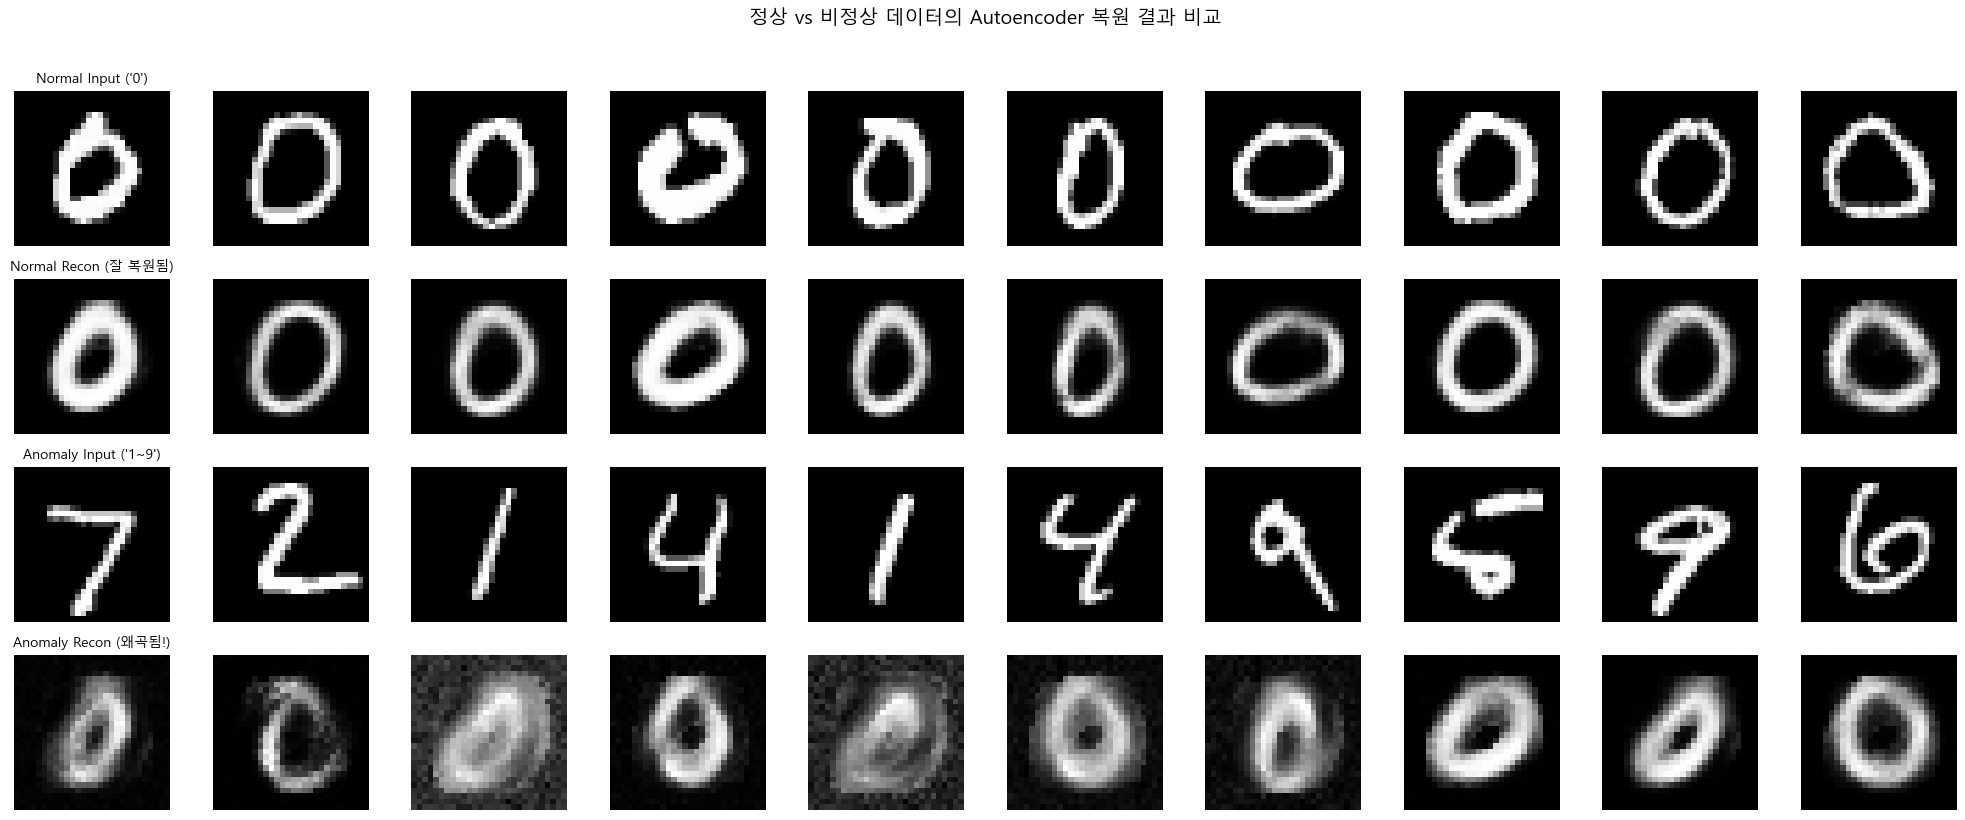

In [15]:
# 정상 샘플과 이상 샘플의 복원 차이 시각적 확인
n = 10
fig, axes = plt.subplots(4, n, figsize=(20, 8))

# 1. 정상 원본 & 복원
for i in range(n):
    axes[0, i].imshow(x_test_normal[i].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")
    if i == 0: axes[0, i].set_title("Normal Input ('0')", fontsize=10)
    
    axes[1, i].imshow(recon_normal[i].reshape(28, 28), cmap="gray")
    axes[1, i].axis("off")
    if i == 0: axes[1, i].set_title("Normal Recon (잘 복원됨)", fontsize=10)

# 2. 비정상 원본 & 복원
for i in range(n):
    axes[2, i].imshow(x_test_anomaly[i].reshape(28, 28), cmap="gray")
    axes[2, i].axis("off")
    if i == 0: axes[2, i].set_title("Anomaly Input ('1~9')", fontsize=10)
    
    axes[3, i].imshow(recon_anomaly[i].reshape(28, 28), cmap="gray")
    axes[3, i].axis("off")
    if i == 0: axes[3, i].set_title("Anomaly Recon (왜곡됨!)", fontsize=10)

plt.suptitle("정상 vs 비정상 데이터의 Autoencoder 복원 결과 비교", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. 실습 요약 및 제조 AI 시사점

1. **Autoencoder의 본질**:
   - 입력과 타겟이 동일한 비지도 학습 구조를 통해 고차원 데이터의 핵심적인 잠재 특징(Latent Feature)을 압축 추출합니다.
2. **Denoising Autoencoder(DAE)**:
   - 인위적으로 노이즈를 더한 입력을 깨끗한 원본으로 복원하도록 학습시켜, 열악한 제조 센서/비전 환경에서도 강건한 디노이징 성능을 발휘합니다.
3. **Reconstruction-based Anomaly Detection**:
   - 대다수를 차지하는 양품(정상 데이터)만으로 모델을 학습한 뒤, 결함품이 들어왔을 때 발생하는 높은 재구성 오차(Reconstruction Error)를 이용해 비지도 결함 검출을 수행하는 실무 표준 기법입니다.